<a href="https://colab.research.google.com/github/hkbk0736-dotcom/GEOG5900M/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This project explores the spatial distribution of street lighting and crime across Leeds using Lower-layer Super Output Areas (LSOAs) as the unit of analysis. The study adopts an exploratory spatial analysis approach, combining point-based datasets with area-level aggregation to examine spatial patterns and associations between street light density and crime density.

# Study Area

The study area is Leeds, England. The spatial framework is based on 2021 Lower-layer Super Output Area (LSOA) boundaries, which provide a consistent areal unit for aggregating and comparing spatial data.

#Data Sources
This report utilizes open spatial data from three primary providers. All data used is under the Open Government Licence v3.0.

## 1. Boundary Data: UK Data Service
* **Dataset**: English Lower Layer Super Output Areas (LSOA) 2021.
* **Purpose**: Provides the census-based geographic units for spatial aggregation.
* [cite_start]**Justification**: LSOA level is chosen because it offers a high resolution (approx. 482 areas in Leeds), providing a sufficient sample size for robust statistical modelling.
* **Source**: [UK Data Service](https://census.ukdataservice.ac.uk/)

## 2. Crime Data: data.police.uk
* **Dataset**: West Yorkshire Police Crime Records.
* **Purpose**: Identifies the locations and types of crimes.
* [cite_start]**Justification**: Filtering for "night-time" crimes (e.g., Robbery) allows for a targeted investigation into the 'public good' aspect of urban lighting[cite: 47, 52].
* **Source**: [data.police.uk](https://data.police.uk/)

## 3. Infrastructure Data: Leeds Data Mill
* **Dataset**: Street lights (unmetered)
* **Purpose**: To map the distribution of lighting assets.
* **Source**: [Leeds Data Mill](https://leedsdatamill.org/)

In [81]:
# Data handling and spatial data processing
import pandas as pd
import geopandas as gpd

# Visualisation and mapping
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx

# Statistical modelling
import statsmodels.api as sm

# Set a clean plotting style suitable for academic figures
sns.set_theme(style="white")

In [82]:
# Load LSOA 2021 boundary data
lsoa_borders = gpd.read_file("data/LSOA_2021_Boundaries.shp")

# The boundary dataset is already restricted to Leeds,
# so no additional spatial filtering is required
leeds_lsoa = lsoa_borders.copy()

# Reproject to British National Grid (EPSG:27700)
leeds_lsoa = leeds_lsoa.to_crs(epsg=27700)

# Sanity check: confirm number of LSOAs
print(leeds_lsoa.shape)

(488, 5)


# Data Cleaning and Preparation

Initial data cleaning focused on ensuring spatial validity and consistency across datasets. Records without valid geographic coordinates were removed from the crime and street lighting datasets to allow reliable spatial analysis.

All spatial data were transformed into the British National Grid coordinate system (EPSG:27700), which is appropriate for spatial joins and area-based calculations.

In [83]:
# Load crime records for Leeds
crime_df = pd.read_csv("data/leeds_crime.csv")

# Remove records without valid longitude or latitude values
# This ensures that only geolocatable incidents are retained
crime_clean = crime_df.dropna(subset=["Longitude", "Latitude"])

# Convert the cleaned crime data to a GeoDataFrame
# Coordinates are provided in WGS84 (EPSG:4326) and are reprojected
# to British National Grid (EPSG:27700) for spatial analysis
crime_gdf = gpd.GeoDataFrame(
    crime_clean,
    geometry=gpd.points_from_xy(
        crime_clean["Longitude"],
        crime_clean["Latitude"]
    ),
    crs="EPSG:4326"
).to_crs(epsg=27700)

In [84]:
# Load Leeds City Council street lighting inventory
lights_df = pd.read_csv("data/leeds_street_lights.csv")

# Remove records without valid British National Grid coordinates
# This ensures that only spatially valid street light locations are retained
lights_clean = lights_df.dropna(subset=["Easting", "Northing"])

# Convert the cleaned data to a GeoDataFrame
# Coordinates are provided in British National Grid (EPSG:27700),
# which is appropriate for spatial joins and area-based analysis
lights_gdf = gpd.GeoDataFrame(
    lights_clean,
    geometry=gpd.points_from_xy(
        lights_clean["Easting"],
        lights_clean["Northing"]
    ),
    crs="EPSG:27700"
)

# Sanity check: inspect available attributes in the street light dataset
print(lights_df.columns.tolist())

['Operational Area', 'Road Name', 'Road Ref.', 'Unit ID', 'Unit Ref', 'Unit Type', 'Unit Location', 'Easting', 'Northing', 'Lamps Per Lantern']


# Spatial Aggregation and Density Measures

Crime incidents and street lighting points were spatially assigned to LSOA polygons using point-in-polygon joins. Counts were aggregated at the LSOA level to obtain the total number of crime incidents and street lights within each area.

To ensure comparability across LSOAs of varying sizes, density measures were calculated by normalising counts by LSOA area (per square kilometre).

In [85]:
# Spatial join: assign each street light to an LSOA polygon
# Points falling within an LSOA are associated with that area
lights_joined = gpd.sjoin(
    lights_gdf,
    leeds_lsoa,
    predicate="within"
)

# Count the number of street lights per LSOA
# Grouping is done using the polygon index (index_right)
light_counts = (
    lights_joined
    .groupby("index_right")
    .size()
    .rename("light_count")
)

# Spatial join: assign each crime incident to an LSOA polygon
crime_joined = gpd.sjoin(
    crime_gdf,
    leeds_lsoa,
    predicate="within"
)

# Count the number of crimes per LSOA
crime_counts = (
    crime_joined
    .groupby("index_right")
    .size()
    .rename("crime_count")
)

# Remove existing count columns to avoid conflicts during re-joining
# This allows the cell to be safely re-run if needed
leeds_lsoa = leeds_lsoa.drop(
    columns=["light_count", "crime_count"],
    errors="ignore"
)

# Join aggregated counts back to the LSOA polygons
# Areas with no incidents are assigned a value of zero
leeds_lsoa = (
    leeds_lsoa
    .join(light_counts)
    .join(crime_counts)
    .fillna(0)
)

In [86]:
# Calculate LSOA area in square kilometres
# British National Grid (EPSG:27700) uses metres, so conversion is required
leeds_lsoa["area_km2"] = leeds_lsoa.geometry.area / 1_000_000

# Calculate density measures (per km²)
# Counts are normalised by area to ensure comparability across LSOAs
leeds_lsoa["light_density"] = (
    leeds_lsoa["light_count"] / leeds_lsoa["area_km2"]
)

leeds_lsoa["crime_density"] = (
    leeds_lsoa["crime_count"] / leeds_lsoa["area_km2"]
)

# Quick diagnostic to inspect the distribution of the derived variables
print(leeds_lsoa[["crime_density", "light_density"]].describe())

       crime_density  light_density
count     488.000000     488.000000
mean       48.945554     508.099435
std        69.139464     316.093208
min         0.000000       1.600764
25%         9.165243     285.510905
50%        27.929621     492.826230
75%        65.099651     671.006323
max       874.187396    1981.586813


In [87]:
# Prepare a dataframe for regression analysis
# Only variables required for the model are retained
reg_df = leeds_lsoa[["crime_density", "light_density"]]

# Define dependent and independent variables
# Crime density is treated as the response variable
# Street light density is included as the explanatory variable
y = reg_df["crime_density"]
X = sm.add_constant(reg_df[["light_density"]])

# Fit an Ordinary Least Squares (OLS) regression model
# The model explores the association between street lighting and crime density
model = sm.OLS(y, X).fit()

# Output model summary for inspection and interpretation
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          crime_density   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     552.6
Date:                Fri, 01 May 2026   Prob (F-statistic):           3.58e-82
Time:                        05:32:14   Log-Likelihood:                -2573.9
No. Observations:                 488   AIC:                             5152.
Df Residuals:                     486   BIC:                             5160.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -32.1195      4.060     -7.911

# Mapping Spatial Patterns

Choropleth maps were used to visualise the spatial distribution of street light density and crime density across Leeds. Densities were classified using a quantile-based scheme to highlight relative spatial variation between LSOAs.

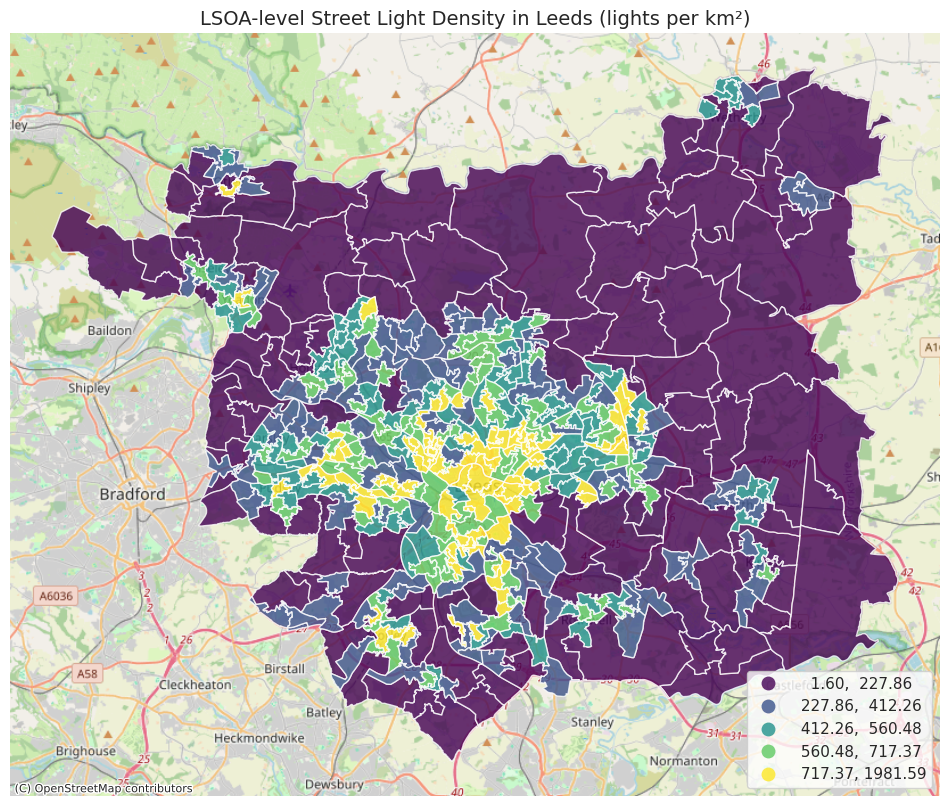

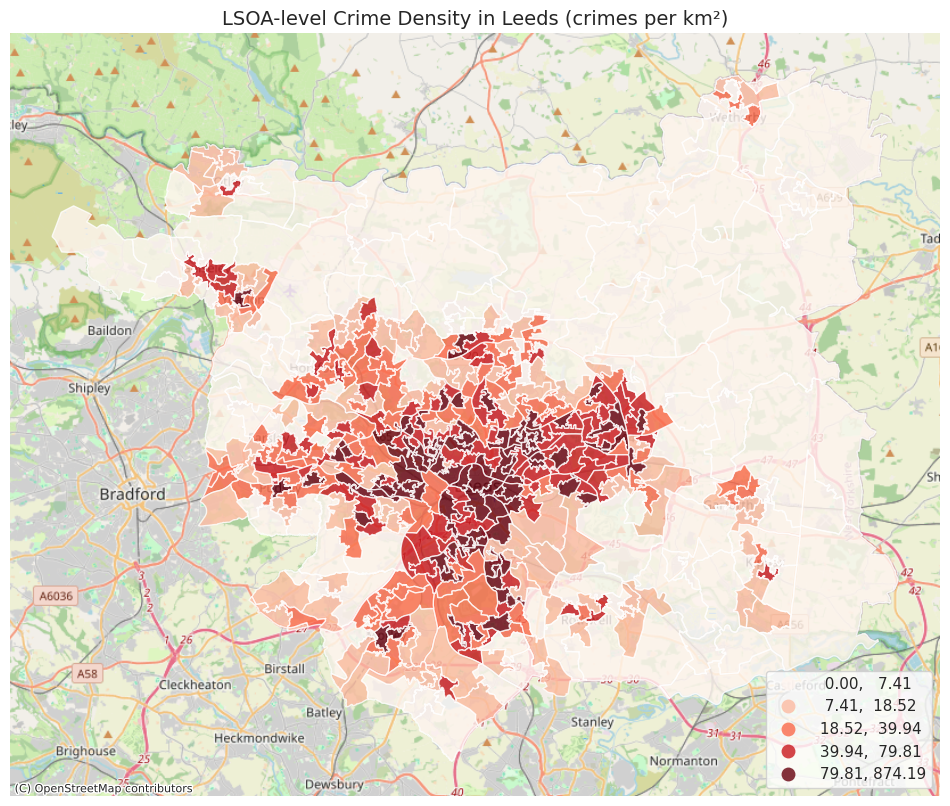

In [88]:
# Reproject LSOA polygons to Web Mercator for web basemap display
# OpenStreetMap basemaps require EPSG:3857
leeds_lsoa_3857 = leeds_lsoa.to_crs(epsg=3857)

# Common plotting parameters to ensure visual consistency
basemap = ctx.providers.OpenStreetMap.Mapnik
figsize = (12, 10)
classification = "Quantiles"
k = 5
opacity = 0.8

# Plot LSOA-level street light density
fig, ax = plt.subplots(1, 1, figsize=figsize)

leeds_lsoa_3857.plot(
    column="light_density",
    ax=ax,
    cmap="viridis",
    scheme=classification,
    k=k,
    legend=True,
    legend_kwds={"loc": "lower right"},
    alpha=opacity
)

# Add OpenStreetMap basemap for spatial context
ctx.add_basemap(ax, source=basemap)

ax.set_title(
    "LSOA-level Street Light Density in Leeds (lights per km²)",
    fontsize=14
)
ax.set_axis_off()

plt.show()

# Plot LSOA-level crime density
fig, ax = plt.subplots(1, 1, figsize=figsize)

leeds_lsoa_3857.plot(
    column="crime_density",
    ax=ax,
    cmap="Reds",
    scheme=classification,
    k=k,
    legend=True,
    legend_kwds={"loc": "lower right"},
    alpha=opacity
)

# Add OpenStreetMap basemap for spatial context
ctx.add_basemap(ax, source=basemap)

ax.set_title(
    "LSOA-level Crime Density in Leeds (crimes per km²)",
    fontsize=14
)
ax.set_axis_off()

plt.show()

# Exploratory Statistical Analysis

To complement the spatial analysis, an exploratory statistical analysis was conducted to examine the association between street light density and crime density at the LSOA level.

A scatter plot with a fitted ordinary least squares (OLS) trend line was used to visualise the relationship between the two variables. An OLS regression model was then estimated to quantify the strength and direction of the association.

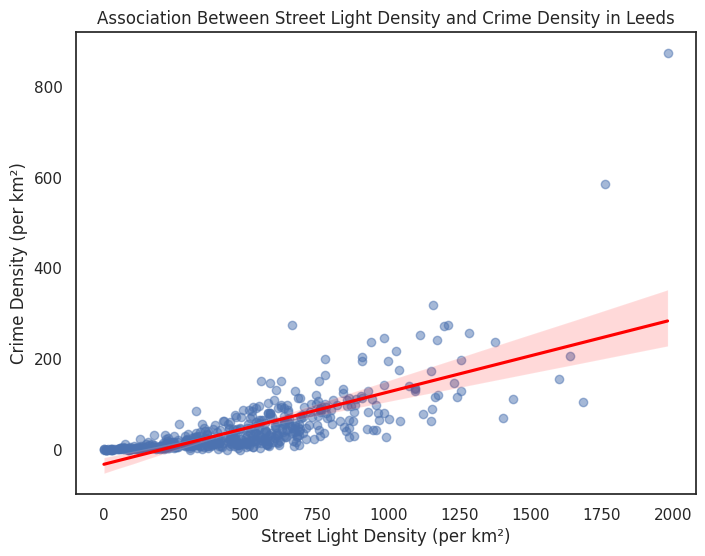

In [89]:
# Visualise the relationship between street light density and crime density
plt.figure(figsize=(8, 6))

sns.regplot(
    x="light_density",
    y="crime_density",
    data=reg_df,
    scatter_kws={"alpha": 0.5},       # semi-transparent points to reduce overplotting
    line_kws={"color": "red"}         # fitted OLS trend line
)

plt.xlabel("Street Light Density (per km²)")
plt.ylabel("Crime Density (per km²)")
plt.title("Association Between Street Light Density and Crime Density in Leeds")

plt.show()